Розмір: (214, 11)
   Id       RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type of glass
0   1  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0              1
1   2  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0              1
2   3  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0              1
3   4  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0              1
4   5  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0              1
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             214 non-null    int64  
 1   RI             214 non-null    float64
 2   Na             214 non-null    float64
 3   Mg             214 non-null    float64
 4   Al             214 non-null    float64
 5   Si             214 non-null    float64
 6   K              214 non-null    float64
 7   Ca             214 

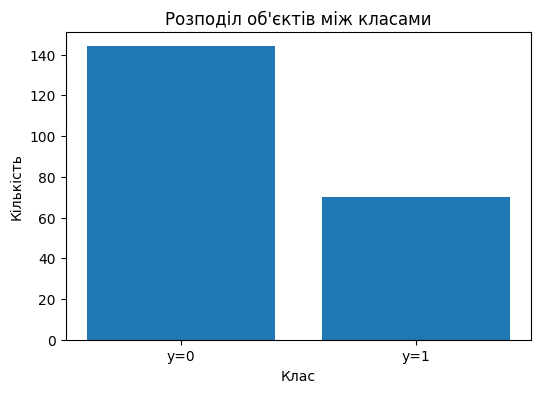


Train: (171, 9)
Test: (43, 9)

Частки класів:
All: 0.32710280373831774
Train: 0.32748538011695905
Test: 0.32558139534883723

Результати Cross-Validation:
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0             Baseline    0.6726     0.0000  0.0000  0.0000   0.5000
1  Logistic Regression    0.7254     0.5871  0.5015  0.5391   0.8080
2           GaussianNB    0.5790     0.4287  0.8439  0.5632   0.7213

Test set:
Accuracy: 0.7209302325581395
Precision: 0.5625
Recall: 0.6428571428571429
F1: 0.6
ROC-AUC: 0.8152709359605912

Confusion Matrix:
[[22  7]
 [ 5  9]]
TN = 22
FP = 7
FN = 5
TP = 9


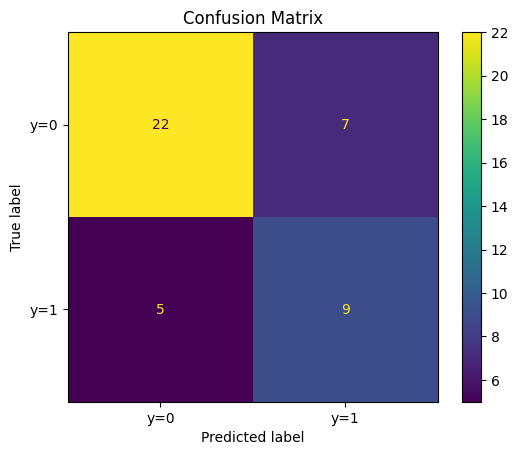


Порівняння результатів:
      Metric  Cross-Validation    Test  Baseline  Test - CV
0   Accuracy            0.7254  0.7209    0.6726    -0.0045
1  Precision            0.5871  0.5625    0.0000    -0.0246
2     Recall            0.5015  0.6429    0.0000     0.1414
3         F1            0.5391  0.6000    0.0000     0.0609
4    ROC-AUC            0.8080  0.8153    0.5000     0.0073

Помилково класифіковані об'єкти:
    Index  Actual  Predicted  Probability Error type         d
11    158       0          1     0.806786         FP  0.306786
6     103       0          1     0.777183         FP  0.277183
7       9       1          0     0.267416         FN  0.232584
8     142       0          1     0.709426         FP  0.209426
9     163       0          1     0.705130         FP  0.205130
4      27       1          0     0.329633         FN  0.170367
2      91       0          1     0.659926         FP  0.159926
3     146       0          1     0.651133         FP  0.151133
0      52     

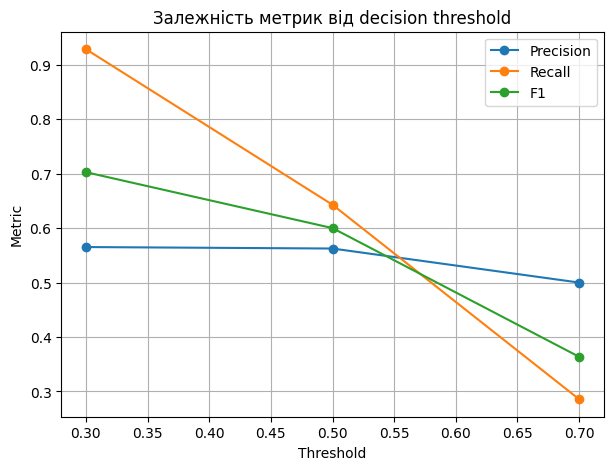

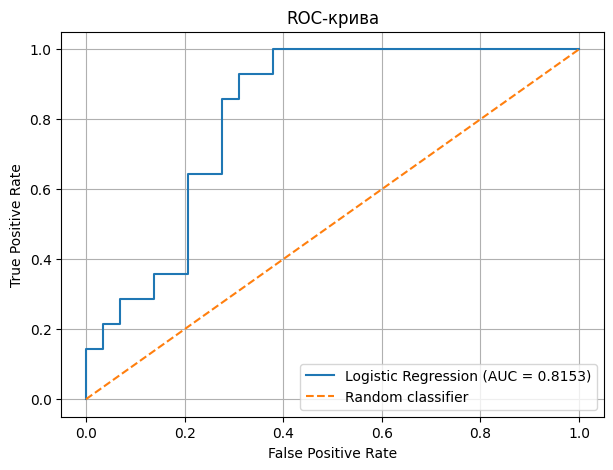

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    make_scorer
)

df = pd.read_csv("glass.csv")

print("Розмір:", df.shape)
print(df.head())
print(df.info())

# Перевірка пропусків та дублікатів
print("\nПропущені значення:")
print(df.isna().sum())

print("\nКількість дублікатів:", df.duplicated().sum())

print("\nРозподіл початкових класів:")
print(df["Type of glass"].value_counts().sort_index())


y = (df["Type of glass"] == 1).astype(int)

X = df.drop(columns=["Id", "Type of glass"])

print("\nБінарний розподіл:")
print(y.value_counts())

print("\nЧастки класів:")
print(y.value_counts(normalize=True))



counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["y=0", "y=1"], counts.values)
plt.xlabel("Клас")
plt.ylabel("Кількість")
plt.title("Розподіл об'єктів між класами")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain:", X_train.shape)
print("Test:", X_test.shape)

print("\nЧастки класів:")
print("All:", y.mean())
print("Train:", y_train.mean())
print("Test:", y_test.mean())


baseline = DummyClassifier(
    strategy="most_frequent"
)

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000))
])

gnb_model = Pipeline([
    ("classifier", GaussianNB())
])


models = {
    "Baseline": baseline,
    "Logistic Regression": logistic_model,
    "GaussianNB": gnb_model
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall": make_scorer(recall_score, zero_division=0),
    "F1": make_scorer(f1_score, zero_division=0),
    "ROC-AUC": "roc_auc"
}

results = []

for name, model in models.items():

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Accuracy": cv_results["test_Accuracy"].mean(),
        "Precision": cv_results["test_Precision"].mean(),
        "Recall": cv_results["test_Recall"].mean(),
        "F1": cv_results["test_F1"].mean(),
        "ROC-AUC": cv_results["test_ROC-AUC"].mean()
    })

results_df = pd.DataFrame(results)

print("\nРезультати Cross-Validation:")
print(results_df.round(4))


model = logistic_model

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print("\nTest set:")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1:", test_f1)
print("ROC-AUC:", test_auc)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["y=0", "y=1"]
).plot()

plt.title("Confusion Matrix")
plt.show()

error_mask = y_test.values != y_pred

error_indices = X_test.index[error_mask]

errors = pd.DataFrame({
    "Index": df.loc[error_indices, "Id"].values,
    "Actual": y_test.loc[error_indices].values,
    "Predicted": y_pred[error_mask],
    "Probability": y_proba[error_mask]
})

errors["Error type"] = np.where(
    (errors["Actual"] == 0) &
    (errors["Predicted"] == 1),
    "FP",
    "FN"
)

errors["d"] = abs(errors["Probability"] - 0.5)

cv_results_lr = {
    "Accuracy": 0.7254,
    "Precision": 0.5871,
    "Recall": 0.5015,
    "F1": 0.5391,
    "ROC-AUC": 0.8080
}

baseline_results = {
    "Accuracy": 0.6726,
    "Precision": 0.0000,
    "Recall": 0.0000,
    "F1": 0.0000,
    "ROC-AUC": 0.5000
}

test_results = {
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC-AUC": test_auc
}

comparison = pd.DataFrame({
    "Metric": list(test_results.keys()),
    "Cross-Validation": list(cv_results_lr.values()),
    "Test": list(test_results.values()),
    "Baseline": list(baseline_results.values())
})

comparison["Test - CV"] = (
    comparison["Test"] - comparison["Cross-Validation"]
)

print("\nПорівняння результатів:")
print(comparison.round(4))


print("\nПомилково класифіковані об'єкти:")
print(errors.sort_values("d", ascending=False))


strong_errors = errors[
    ((errors["Actual"] == 1) & (errors["Probability"] < 0.5)) |
    ((errors["Actual"] == 0) & (errors["Probability"] > 0.5))
]

print("\nСильно впевнені неправильні прогнози:")
print(strong_errors)


threshold_results = []

for threshold in [0.3, 0.5, 0.7]:

    pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred_threshold
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred_threshold,
            zero_division=0
        ),
        "FP": fp,
        "FN": fn
    })

threshold_df = pd.DataFrame(threshold_results)

print("\nDecision Threshold:")
print(threshold_df.round(4))


plt.figure(figsize=(7, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Залежність метрик від decision threshold")
plt.legend()
plt.grid(True)
plt.show()


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-крива")
plt.legend()
plt.grid(True)
plt.show()